In [5]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os
import sys

parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# MPC import
import numpy as np
from LinearMPC_part_3.MPCVelControl import MPCVelControl
from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



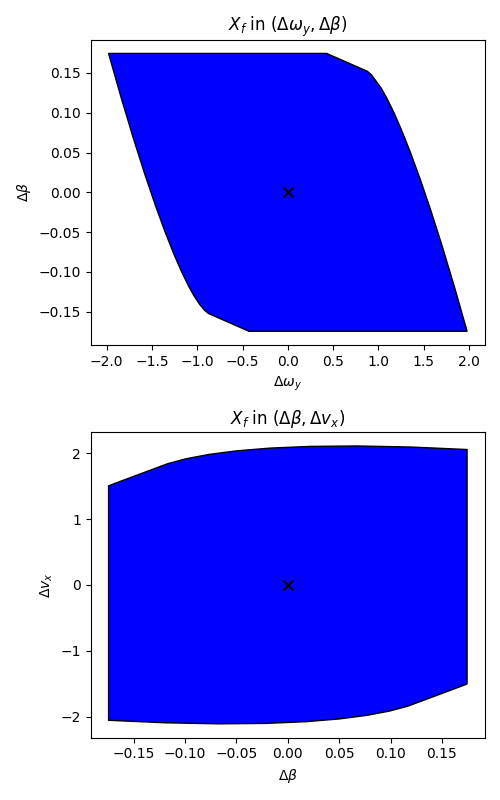

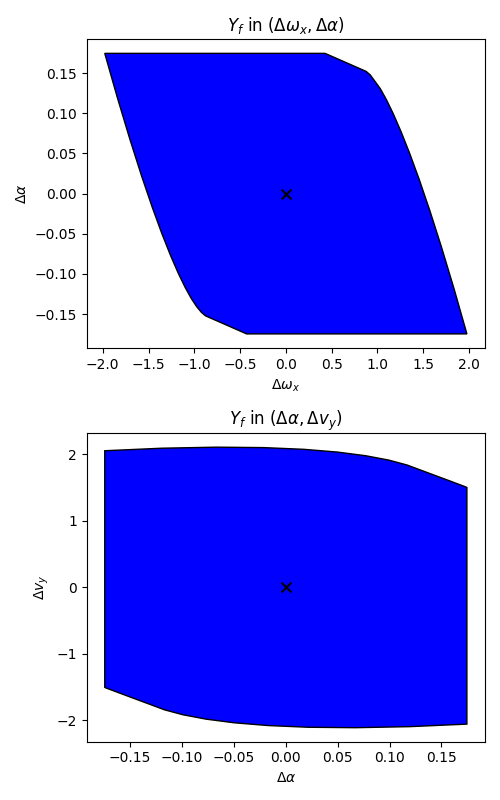

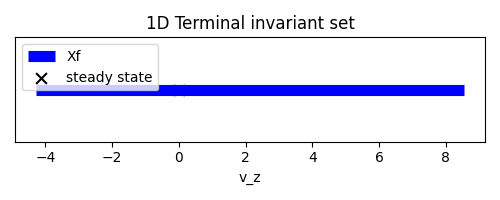

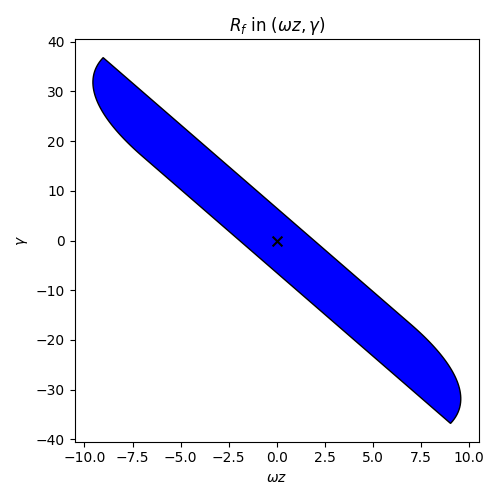

[0. 0. 5.]


C:\Users\Aayushi Barve\AppData\Roaming\Python\Python312\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Simulating time 0.00: [0. 0. 5.]

Simulating time 0.05: [-0.85706121 -0.02142653  5.12485806]

Simulating time 0.10: [-1.57429901 -0.08221054  5.20833556]

Simulating time 0.15: [-0.8748573  -0.14343944  5.04683497]

Simulating time 0.20: [-0.20194515 -0.1703595   4.86775212]

Simulating time 0.25: [ 0.025036   -0.17478223  4.74868253]

 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.30: [-0.01297304 -0.17448066  4.6688309 ]

Simulating time 0.35: [ 0.0063508  -0.17464622  4.58030889]

 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.40: [-1.85827870e-03 -1.74533903e-01  4.49595361e+00]

Simulating time 0.45: [ 1.85720426e-03 -1.74533930e-01  4.40981558e+00]

Simulating time 0.50: [ 5.56041910e-04 -1.74473598e-01  4.32445391e+00]

Simulating time 0.55: [-1.19472955e-03 -1.74489566e-01  4.23917138e+00]

Simulating time 0.60: [ 7.74157876e-04 -1.74500080e-01  4.15331767e+00]

Simulating time 0.65

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x00000210C4E06080> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x00000210C4E06080> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_cont

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=99, step=2), IntSlider(value=0,…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\alpha\\beta\\gamma}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: >,
  <Axes: ylabel='$\\alpha\\beta\\gamma$ (deg)'>,
  <Axes: >,
  <Axes: ylabel='$v$ (m/s)'>,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: ylabel='$\\text{pos}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x211f39c1e50>,
 'scene_objects': {'rocket_actor': Actor (0x211f3007820)
    Center:                     (-0.06306123784072204, -0.18374197419077526, 0.5884844999999999)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    -1.125E+00, 9.985E-01
    Y Bounds                    -1.210

 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'shading'


In [3]:
Ts = 0.05
sim_time = 5
H = 15

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
x0 = np.array([0.0, 0.0 ,0.0 ,0.0 ,0.0 ,np.deg2rad(40),5.0 ,5.0 ,5.0 ,0.0 ,0.0 ,0.0])
mpc = MPCVelControl().new_controller(rocket, Ts, H)

u0, t_traj, x_traj, u_traj = mpc.get_u(0, x0)

t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, _ = rocket.simulate_control(
    mpc, sim_time, H, x0, method="linear"
)

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:, :-1], u_cl, T_ol=t_ol[..., :-1], X_ol=x_ol, U_ol=u_ol)



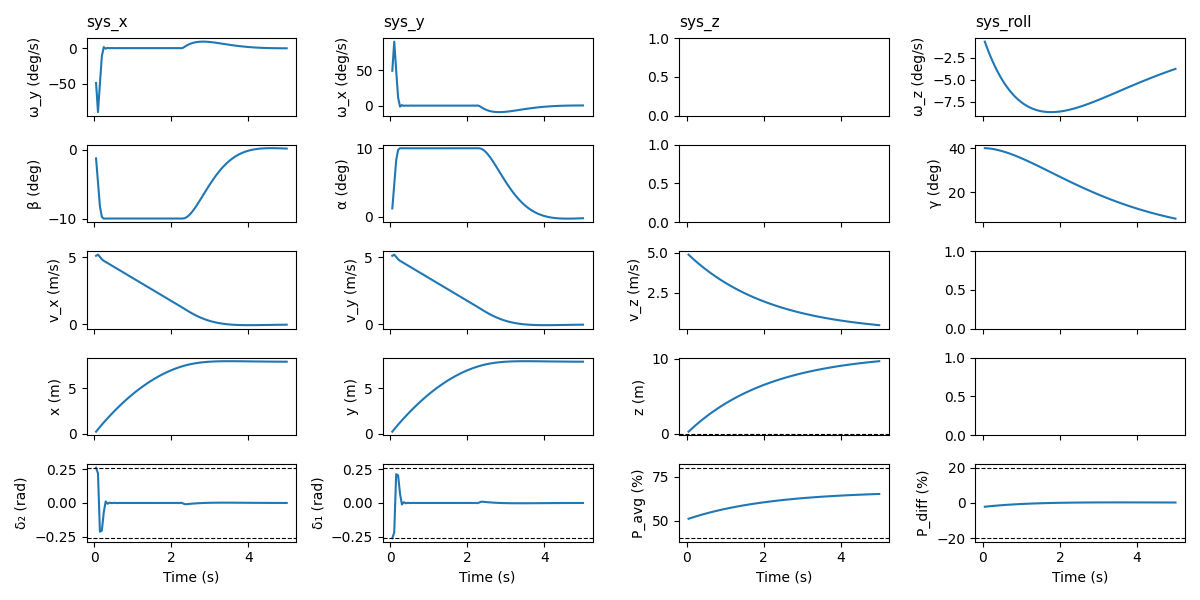

In [4]:
plot_static_states_inputs(t_cl[1:],x_cl[:,1:],u_cl)

In [12]:
print(t_ol.shape)
print(t_ol[:,1:].shape)
print(u_ol.shape)
print(u_ol[1,:,:].shape)

print(x_ol.shape)
print(x_ol[1,1:,1:].shape)

(301, 101)
(301, 100)
(4, 300, 100)
(300, 100)
(12, 301, 101)
(300, 100)


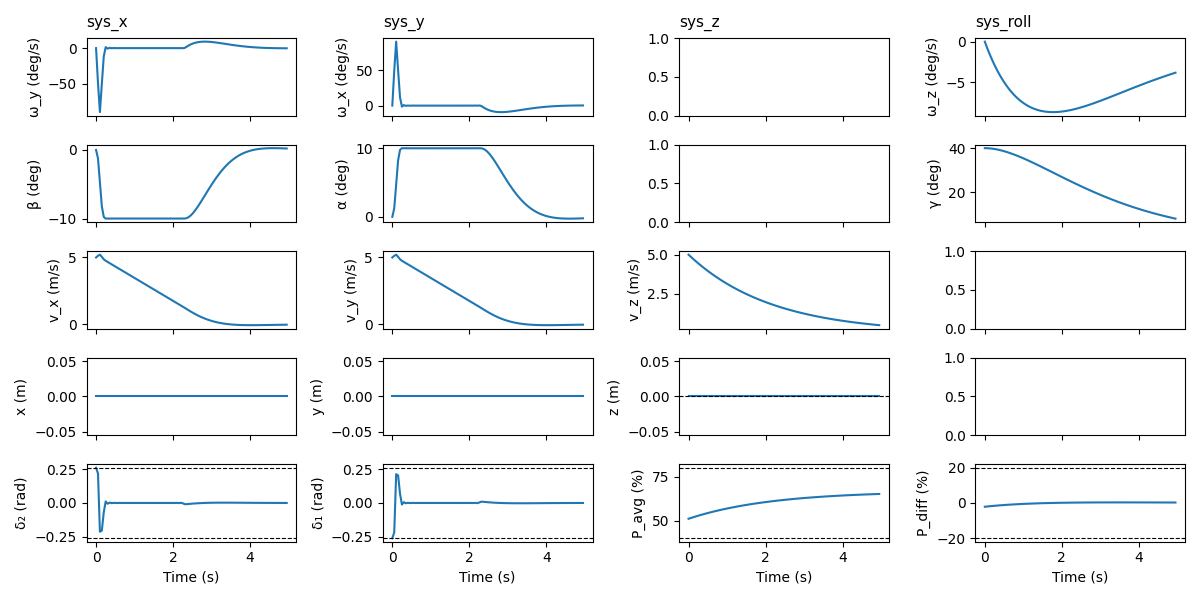

In [13]:
k = 0

t_pred = t_ol[k, :-1]        
x_pred = x_ol[:, k, :-1]    
u_pred = u_ol[:, k, :]    

plot_static_states_inputs(t_pred,x_pred,u_pred)